# Exploratory Data Analysis (EDA)

Este notebook contiene el análisis exploratorio del dataset `credir_risk_reto.csv` para entender sus características y preparar el flujo de procesamiento.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset
file_path = '../data/credir_risk_reto.csv'
df = pd.read_csv(file_path)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [8]:
df.isnull().sum()  # Verificar valores nulos

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
dtypes: int64(4), object(5)
memory usage: 70.4+ KB


## Estadísticas básicas

In [4]:
df.describe(include='all')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
count,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000
unique,NaN,2,NaN,3,4,3,NaN,NaN,8
top,NaN,male,NaN,own,little,little,NaN,NaN,car
freq,NaN,690,NaN,713,603,274,NaN,NaN,337
mean,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN
std,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN
min,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN
25%,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN
50%,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN
75%,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN


## Distribución de variables categóricas

In [5]:
# Distribución de 'Job'
job_counts = df['Job'].value_counts()
print('Distribución Job:')
print(job_counts)

# Distribución de 'Housing'
housing_counts = df['Housing'].value_counts()
print('Distribución Housing:')
print(housing_counts)

# Distribución de 'Purpose'
purpose_counts = df['Purpose'].value_counts()
print('Distribución Purpose:')
print(purpose_counts)

Distribución Job:
Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64
Distribución Housing:
Housing
own     713
rent    179
free    108
Name: count, dtype: int64
Distribución Purpose:
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64


## Visualización de variables numéricas

OptionError: No such keys(s): 'mode.use_inf_as_null'

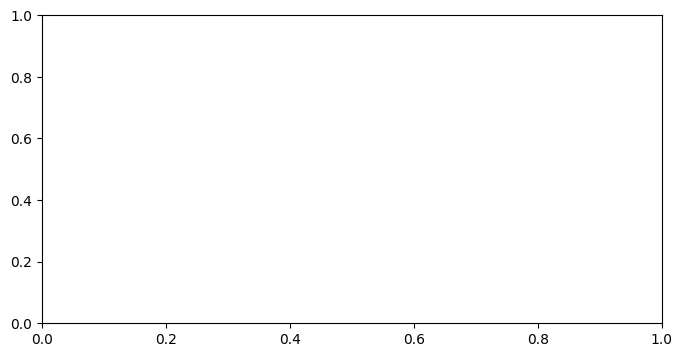

In [12]:
# Histograma de Credit amount
plt.figure(figsize=(8,4))
sns.histplot(df['Credit amount'])
plt.title('Distribución de Credit amount')
plt.show()

# Histograma de Duration
plt.figure(figsize=(8,4))
sns.histplot(df['Duration'], bins=30, kde=True)
plt.title('Distribución de Duration')
plt.show()

## Correlaciones entre variables numéricas

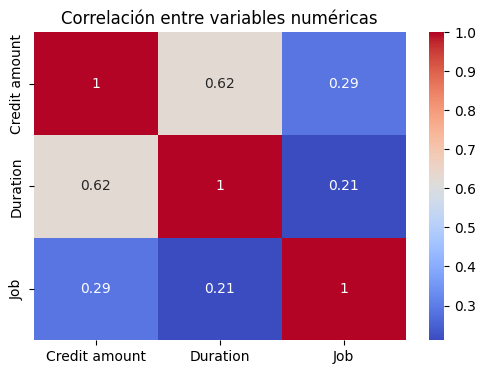

In [7]:
correlation = df[['Credit amount', 'Duration', 'Job']].corr()
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlación entre variables numéricas')
plt.show()

## Observaciones y recomendaciones
- El dataset contiene variables categóricas y numéricas relevantes para el riesgo crediticio.
- Revisar valores nulos y outliers antes de modelar.
- Analizar la relación entre "Purpose" y las variables numéricas para futuras etapas.

## Consideraciones sobre valores nulos y el uso de LLMs

En este dataset, las columnas "Saving accounts" y "Checking account" contienen valores nulos. Si se utiliza un modelo generativo (LLM) como GPT o Llama para crear descripciones, el modelo puede manejar estos valores ausentes de forma natural, generando texto que ignore o complete la información faltante. Por lo tanto, no es estrictamente necesario imputar estos valores antes de la generación de descripciones.

Sin embargo, para tareas de modelado clásico (por ejemplo, entrenamiento de modelos supervisados), es recomendable decidir una estrategia para tratar los valores nulos: imputación, codificación como 'unknown', o exclusión de filas. Documenta la decisión tomada y su impacto en el flujo.